# This file is for visualizing all data needed for the project from the ENTSO-E Transparency Platform (TP)

---

ENTSO-E data: 
- Library documentation at: https://github.com/EnergieID/entsoe-py
- API documentation at: https://documenter.getpostman.com/view/7009892/2s93JtP3F6

---

SMHI data
- REST API documentation at: https://opendata-download-metobs.smhi.se/metobs/api

---

The data that is imported and visualized is:
- **ENTSO-E Histroical Actual load in SE1 / SE2 / SE3 / SE4 hourly from 2015** (for training, feautre enginnering, testing and evaluting)
- **ENTSO-E Historical day-ahead load forecasts archive of TSO forecasts** (for evaluating)
- **SMHI / ERA5 Historical weather observations Temp · Wind · Irradiance** (for trainging and feature engineering)
- **Open-Meteo Historical Forecast API NWP model output archive from 2017** (for trainging and feature engineering)
- **SMHI/Open-Meteo Live Forecast API Current NWP model run** (for live version)
- **ENTSO-E Live day-ahead load forecast current TSO forecast published today for tomorrow** (for live version)
- **ENTSO-E Latest actual load real-time measured load per bidding area SE1 to SE4** (for live version)

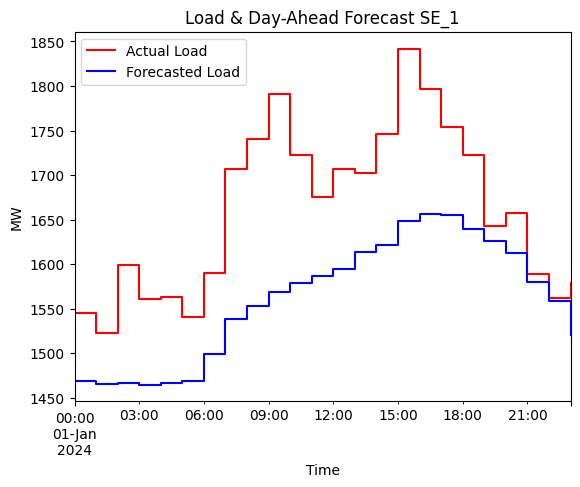

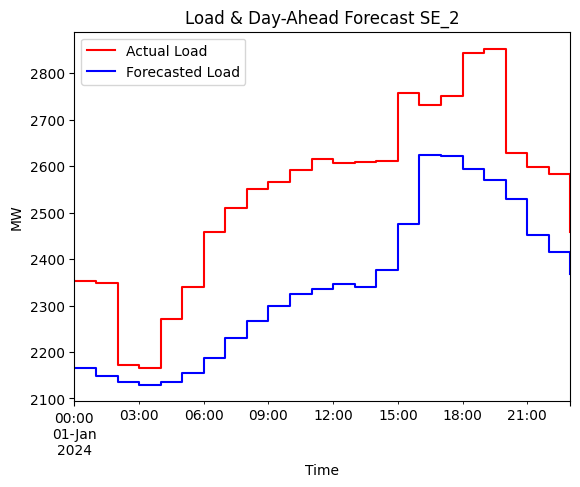

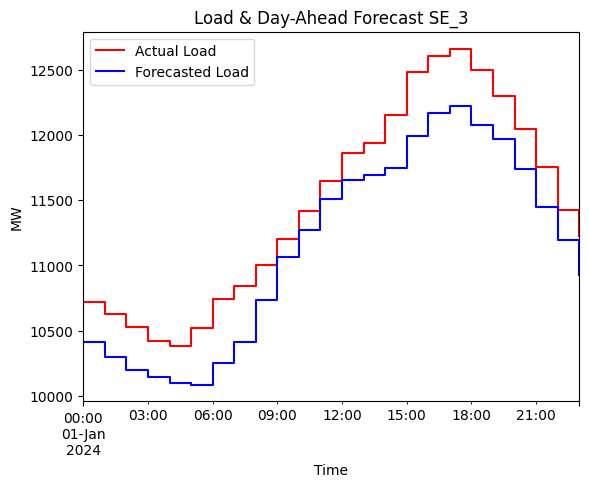

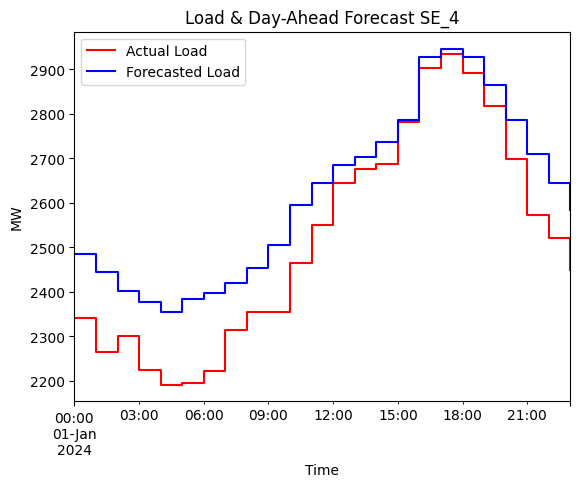

In [ ]:
#########################################
# ENTSO-E Data from Transparency Platform
#########################################

# Import necessary libraries
from dotenv import load_dotenv
import os
import pandas as pd
from entsoe import EntsoePandasClient   # pip install entsoe-py

# Load the API key from the .env file
load_dotenv()
api_key = os.getenv("ENTSOE_API_KEY")

# Initialize the client with the API key
client = EntsoePandasClient(api_key)

# Define the time range and time zone for data retrieval
start = pd.Timestamp("2024-01-01", tz="Europe/Stockholm")
end   = pd.Timestamp("2024-01-02", tz="Europe/Stockholm")

# Specify the time bidding area for the data retrieval
zones = ["SE_1", "SE_2", "SE_3", "SE_4"]  # Sweden bidding zone 3

# Retrive the load data for Sweden bidding zones from the ENTSO-E API
loads = {}
day_ahead_forecasts = {}

for zone in zones:
    # Query the load data for the specified zone and time range
    load = client.query_load(zone, start=start, end=end)

    day_ahead_forecast = client.query_load_forecast(zone, start=start, end=end)
    # Not possible to specify day ahead or week ahead forecast, so it seems to return the day ahead forecast by default. Checked with:
    #   import inspect
    #   from entsoe import EntsoeRawClient
    #   print(inspect.getsource(EntsoeRawClient.query_load_forecast))
    """
    Day ahead forecast explanation:
    - The day-ahead forecast for all hours of day D is produced in a single run on day D-1, typically around 12:00–14:00 CET after the day-ahead market auction clears.
    - So for example, the forecast for every hour of 2024-01-02 (00:00 through 23:00) was all produced on 2024-01-01 in one batch — not hour-by-hour.
    """
    
    # Store by zone name
    loads[zone] = load
    day_ahead_forecasts[zone] = day_ahead_forecast

# Print results using matplotlib
import matplotlib.pyplot as plt

for zone in zones:
    load = loads[zone]
    day_ahead_forecast = day_ahead_forecasts[zone]

    fig, ax = plt.subplots()
    load.plot(ax=ax, label="Load", color="red", drawstyle="steps-post")
    day_ahead_forecast.plot(ax=ax, label="Day-Ahead Forecast", color="blue", drawstyle="steps-post")

    ax.set_title(f"Load & Day-Ahead Forecast {zone}")
    ax.set_ylabel("MW")
    ax.set_xlabel("Time")
    ax.legend()
    plt.show()

"""
Conclusion:
- Possible to retrieve both actual load and day-ahead forecast for the same time range and zone.
- The API is well documented and querries can be tested using:
import inspect
from entsoe import EntsoeRawClient
print(inspect.getsource(EntsoeRawClient.query_load))
"""

In [17]:
###################################
# SMHI Data from SMHI Open Data API
###################################

"""
What is does contain:
- Historical weather observations
- Live/current weather forcasts

What is doesn't contain:
- Historical weather forecasts
"""

# All dates in the JSON answers are in Unix time stamp.
# All Data are available as CSV, XML and JSON data mostly avaialble, ATOM some availability. No default.

import io
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Config

# --- Station ---
STATION_ID = 98160  # Skarpö A, link: https://www.smhi.se/data/hitta-data-for-en-plats/ladda-ner-vaderobservationer/airtemperatureInstant/98160

# --- Time period ---
START_DATE = '2022-01-01'
END_DATE   = '2026-01-01'

# --- API base ---
BASE_URL = 'https://opendata-download-metobs.smhi.se/api/version/latest'

# --- Parameters to extract ---
# Format:  'parameter_name': parameter_id
PARAMETERS = {
    'wind_speed':         4,   # Mean 10-min wind speed                 [m/s]  @ 10 m
    'wind_direction':     3,   # Mean 10-min wind direction             [deg]  @ 10 m
    'wind_gust':         21,   # Max 3-s wind gust                      [m/s]  @ 10 m
    #'global_irradiance': 11,   # Global irradiance                      [W/m²]
    'total_cloud':       16,   # Total cloud cover, momentary value 1/h [%] 
    'temperature':        1,   # Hourly air temperature                 [°C]   @ 2 m
    'precipitation':      7,   # Hourly precipitation                   [mm]
    'relative_humidity':  6,   # Relative humidity                      [%]    @ 2 m
}

PARAM_SUN = {
    'global_irradiance': 11,   # Global irradiance                      [W/m²]
}

def get_stations_info() -> dict:
    """
    Fetch metadata for one station from a parameter's station list.
    Base assupmtion: if parameter 1 (temperature) isn't available, no other parameter will be.
    """
    base_param_id = 1
    url = f"{BASE_URL}/parameter/{base_param_id}.json"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    stations = resp.json().get('station', [])
    return stations

def get_sun_stations_info(solar_id: int) -> dict:
    """
    Fetch metadata for one station from the global irradiance parameter's station list.
    """
    url = f"{BASE_URL}/parameter/{solar_id}.json"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    stations = resp.json().get('station', [])
    return stations

# Uses the temperature parameter (1) as the reference for station metadata under the hood
info_all_stations = get_stations_info()

# Solar measurment station have to be treated seperately
info_all_solar_stations = get_sun_stations_info(PARAM_SUN['global_irradiance'])

df_all_stations = pd.DataFrame(info_all_stations)
df_all_solar_strations = pd.DataFrame(info_all_solar_stations)

df_all_active_stations = df_all_stations[df_all_stations['active'] == True]
df_all_active_solar_stations = df_all_solar_strations[df_all_solar_strations['active'] == True]

active_station_list = df_all_active_stations['id'].tolist()
active_solar_station_list = df_all_active_solar_stations['id'].tolist()

In [ ]:
def filter_stations(station_ids: list, param_dic: dict, start: str = START_DATE):
    """
    Return station IDs that measure all PARAMETERS with data from
    `start` to now. Uses only the parameter station-list JSONs — no CSV fetches.
    """
    start_ts = pd.Timestamp(start, tz='UTC')

    qualifying = set(station_ids)

    for param_name, param_id in param_dic.items():
        resp = requests.get(f"{BASE_URL}/parameter/{param_id}.json", timeout=30)
        resp.raise_for_status()

        covered = {
            s['id']
            for s in resp.json().get('station', [])
            if s['id'] in qualifying
            and pd.to_datetime(s.get('from'), unit='ms', utc=True) <= start_ts
        }

        qualifying &= covered
        print(f"  {param_name:25s} → {len(covered):4d} stations cover the period  |  {len(qualifying)} still qualify")

    return sorted(qualifying)


qualifying_stations = filter_stations(active_station_list)
print(f"\n{len(qualifying_stations)} stations qualify: {qualifying_stations}")

  wind_speed                →  193 stations cover the period  |  193 still qualify
  wind_direction            →  193 stations cover the period  |  193 still qualify
  wind_gust                 →  158 stations cover the period  |  158 still qualify
  total_cloud               →  120 stations cover the period  |  120 still qualify
  temperature               →  120 stations cover the period  |  120 still qualify
  precipitation             →  116 stations cover the period  |  116 still qualify
  relative_humidity         →  116 stations cover the period  |  116 still qualify

116 stations qualify: [52240, 53530, 54290, 62260, 63160, 63510, 64020, 65090, 65160, 65510, 66110, 68560, 71190, 71380, 71420, 72090, 73480, 74180, 74300, 75250, 75520, 77210, 78280, 78400, 78550, 81050, 81540, 82260, 82360, 83190, 83420, 84310, 84340, 84520, 85050, 85240, 85390, 85460, 86340, 86420, 87140, 87440, 89230, 92130, 92410, 93520, 94190, 94390, 95130, 95540, 96040, 96190, 96560, 97370, 97530, 98040, 981